### Deep learning model training.


In [2]:
import time
import torch
import random
import pandas as pd
import torch.nn as nn
from glob import glob
from notebooks import config
from torchinfo import summary
from utils.imgShow import imsShow
from utils.utils import read_scenes
from utils.metrics import oa_binary, miou_binary
from utils.dataloader import SceneArraySet, PatchSet
from model.seg import unet, deeplabv3plus, deeplabv3plus_mobilev2



### dataset loading

In [3]:
### secene and truth pairwise data
## traset
paths_scene = sorted(glob(config.dir_scene + '/*_nor.tif'))
paths_truth = [config.dir_truth + 
               '/' + 
               path.split('/')[-1].replace('_6Bands', '').replace('_nor', '_Truth') \
               for path in paths_scene]
paths_scene_tra = paths_scene[20:]
paths_truth_tra = paths_truth[20:]
## valset
paths_patch_valset = sorted(glob(config.dir_valset + '/*'))
print(f'train scenes: {len(paths_scene_tra)}, vali patch: {len(paths_patch_valset)}')


train scenes: 75, vali patch: 275


In [6]:
scenes_arr, truths_arr = read_scenes(paths_scene_tra, paths_truth_tra) 

In [15]:
## Create dataset instances
tra_data = SceneArraySet(scenes_arr=scenes_arr, 
                         truths_arr=truths_arr, 
                         path_size=(256, 256))
val_data = PatchSet(paths_valset=paths_patch_valset)


In [18]:
tra_loader = torch.utils.data.DataLoader(tra_data, 
                                         batch_size=4, 
                                         shuffle=True, 
                                         num_workers=10)
val_loader = torch.utils.data.DataLoader(val_data, 
                                         batch_size=4)


#### Model training

In [19]:
### check model
model = unet(num_bands=6, num_classes=2)
# model = deeplabv3plus(num_bands=6)
# model = deeplabv3plus_mobilev2(num_bands=6)
summary(model, input_size=(1,6,256,256), device='cpu') 


Layer (type:depth-idx)                   Output Shape              Param #
unet                                     [1, 1, 256, 256]          --
├─ModuleList: 1-1                        --                        --
│    └─dsample: 2-1                      [1, 16, 128, 128]         384
│    │    └─AvgPool2d: 3-1               [1, 6, 128, 128]          --
│    │    └─Sequential: 3-2              [1, 32, 128, 128]         1,824
│    │    └─Sequential: 3-3              [1, 32, 128, 128]         384
│    │    └─Sequential: 3-4              [1, 16, 128, 128]         560
│    └─dsample: 2-2                      [1, 16, 64, 64]           768
│    │    └─AvgPool2d: 3-5               [1, 16, 64, 64]           --
│    │    └─Sequential: 3-6              [1, 64, 64, 64]           9,408
│    │    └─Sequential: 3-7              [1, 64, 64, 64]           768
│    │    └─Sequential: 3-8              [1, 16, 64, 64]           1,072
│    └─dsample: 2-3                      [1, 32, 32, 32]           1,53

In [20]:
### create loss and optimizer
loss_bce = nn.BCELoss()     
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)


In [21]:
'''------train step------'''
def train_step(model, loss_fn, optimizer, x, y):
    optimizer.zero_grad()
    pred = model(x)
    loss = loss_fn(pred, y.float())
    loss.backward()
    optimizer.step()
    miou = miou_binary(pred=pred, truth=y, device=x.device)
    oa = oa_binary(pred=pred, truth=y, device=x.device)
    return loss, miou, oa

'''------validation step------'''
def val_step(model, loss_fn, x, y):
    model.eval()
    with torch.no_grad():
        pred = model(x.float())
        loss = loss_fn(pred, y.float())
    miou = miou_binary(pred=pred, truth=y, device=x.device)
    oa = oa_binary(pred=pred, truth=y, device=x.device)
    return loss, miou, oa

'''------train loops------'''
def train_loops(model, loss_fn, optimizer, tra_loader, 
                                    val_loader, epoches, device):
    tra_loss_loops, tra_miou_loops, tra_oa_loops = [], [], []
    val_loss_loops, val_miou_loops, val_oa_loops = [], [], []
    model = model.to(device)
    size_tra_loader = len(tra_loader)
    size_val_loader = len(val_loader)
    for epoch in range(epoches):
        start = time.time()
        tra_loss, val_loss = 0, 0
        tra_miou, val_miou = 0, 0
        tra_oa, val_oa = 0, 0
        '''-----train the model-----'''
        for x_batch, y_batch in tra_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            loss, miou, oa = train_step(model=model, loss_fn=loss_fn, 
                                    optimizer=optimizer, x=x_batch, y=y_batch)
            tra_loss += loss.item()
            tra_miou += miou.item()
            tra_oa += oa.item()
        '''-----validation the model-----'''
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            loss, miou, oa = val_step(model=model, loss_fn=loss_fn, 
                                                    x=x_batch, y=y_batch)
            val_loss += loss.item()
            val_miou += miou.item()
            val_oa += oa.item()
        ## Accuracy
        tra_loss = tra_loss/size_tra_loader
        val_loss = val_loss/size_val_loader
        tra_miou = tra_miou/size_tra_loader
        val_miou = val_miou/size_val_loader
        tra_oa = tra_oa/size_tra_loader
        val_oa = val_oa/size_val_loader
        tra_loss_loops.append(tra_loss), tra_miou_loops.append(tra_miou), tra_oa_loops.append(tra_oa)
        val_loss_loops.append(val_loss), val_miou_loops.append(val_miou), val_oa_loops.append(val_oa)
        print(f'Ep{epoch+1}: tra-> Loss:{tra_loss:.3f},Oa:{tra_oa:.2f},Miou:{tra_miou:.2f}, '
            f'val-> Loss:{val_loss:.2f},Oa:{val_oa:.2f},Miou:{val_miou:.2f},time:{time.time()-start:.0f}s')
        ## show the result
        if (epoch+1)%20 == 0:
            model.eval()
            sam_index = random.randrange(len(val_data))
            patch, truth = val_data[sam_index]
            patch, truth = torch.unsqueeze(patch.float(), 0).to(device), truth.to(device)
            pred = model(patch)
            ## convert to numpy and plot
            patch = patch[0].to('cpu').detach().numpy().transpose(1,2,0)
            pred = pred[0].to('cpu').detach().numpy()
            truth = truth.to('cpu').detach().numpy()
            imsShow([patch, truth, pred], 
                    img_name_list=['input_patch', 'truth', 'prediction'] , figsize=(10,4))
    metrics = {'tra_loss':tra_loss_loops, 'tra_miou':tra_miou_loops, 'tra_oa': tra_oa_loops, 
                'val_loss': val_loss_loops, 'val_miou': val_miou_loops, 'val_oa': val_oa_loops}
    return metrics  


Ep1: tra-> Loss:2.003,Oa:0.56,Miou:0.27, val-> Loss:13.09,Oa:0.50,Miou:0.39,time:6s


Ep2: tra-> Loss:10.967,Oa:0.52,Miou:0.39, val-> Loss:6.89,Oa:0.55,Miou:0.44,time:5s
Ep3: tra-> Loss:15.967,Oa:0.50,Miou:0.39, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep4: tra-> Loss:20.765,Oa:0.50,Miou:0.39, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep5: tra-> Loss:23.178,Oa:0.50,Miou:0.38, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep6: tra-> Loss:22.179,Oa:0.49,Miou:0.38, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep7: tra-> Loss:23.038,Oa:0.50,Miou:0.38, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep8: tra-> Loss:20.424,Oa:0.51,Miou:0.39, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:6s
Ep9: tra-> Loss:27.196,Oa:0.50,Miou:0.36, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep10: tra-> Loss:20.498,Oa:0.51,Miou:0.39, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep11: tra-> Loss:21.424,Oa:0.50,Miou:0.39, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep12: tra-> Loss:23.115,Oa:0.51,Miou:0.38, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep13: tra-> Loss:24.245,Oa:0.49,Miou:0.37, val-> Loss:21.45,Oa:

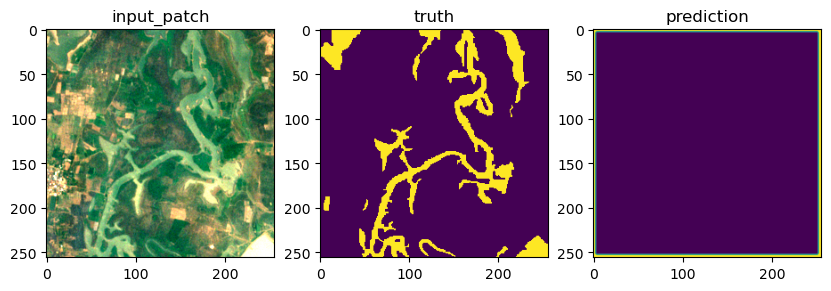

Ep21: tra-> Loss:20.898,Oa:0.50,Miou:0.39, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep22: tra-> Loss:18.545,Oa:0.50,Miou:0.40, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep23: tra-> Loss:22.059,Oa:0.49,Miou:0.38, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep24: tra-> Loss:19.532,Oa:0.50,Miou:0.40, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep25: tra-> Loss:18.911,Oa:0.49,Miou:0.40, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep26: tra-> Loss:26.297,Oa:0.50,Miou:0.36, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:6s
Ep27: tra-> Loss:25.887,Oa:0.49,Miou:0.37, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep28: tra-> Loss:22.985,Oa:0.49,Miou:0.38, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep29: tra-> Loss:21.290,Oa:0.50,Miou:0.39, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:6s
Ep30: tra-> Loss:21.876,Oa:0.50,Miou:0.39, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep31: tra-> Loss:23.020,Oa:0.50,Miou:0.38, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep32: tra-> Loss:18.235,Oa:0.51,Miou:0.41, val-> Loss:

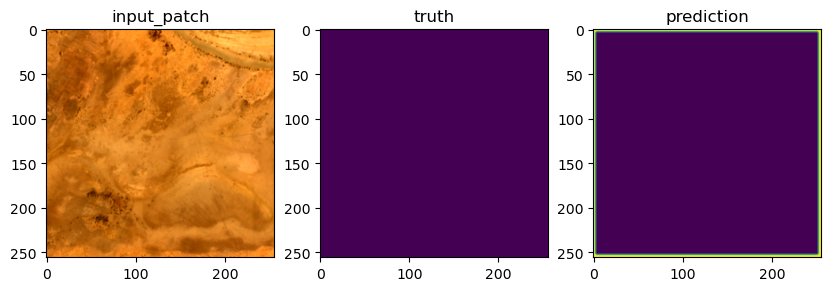

Ep41: tra-> Loss:20.878,Oa:0.50,Miou:0.39, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep42: tra-> Loss:19.847,Oa:0.50,Miou:0.40, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:6s
Ep43: tra-> Loss:19.063,Oa:0.51,Miou:0.40, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep44: tra-> Loss:22.025,Oa:0.51,Miou:0.39, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep45: tra-> Loss:23.319,Oa:0.50,Miou:0.38, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep46: tra-> Loss:20.134,Oa:0.50,Miou:0.40, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep47: tra-> Loss:22.829,Oa:0.50,Miou:0.38, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep48: tra-> Loss:19.477,Oa:0.50,Miou:0.40, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s
Ep49: tra-> Loss:16.843,Oa:0.50,Miou:0.41, val-> Loss:21.45,Oa:0.50,Miou:0.39,time:5s


In [ ]:
device = torch.device('cuda') 
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
metrics = train_loops(model=model, 
              epoches=200,  
              loss_fn=loss_bce, 
              optimizer=optimizer, 
              tra_loader=tra_loader,   
              val_loader=val_loader,  
              device=device)     


In [ ]:
## model saving
net_name = 'unet'
# net_name = 'deeplabv3plus'
# net_name = 'deeplabv3plus_mobilev2'
path_save = f'model/trained/{net_name}_weights.pth'
torch.save(model.state_dict(), path_save)   # save weights of the trained model 
# model.load_state_dict(torch.load(path_save, weights_only=True))  # load the weights of the trained model

## metrics saving
path_metrics = f'model/trained/{net_name}_metrics.csv'
metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(path_metrics, index=False, sep=',')

